In [1]:
from utils import *

Path to dataset files: /Users/jfranciscocmorais/.cache/kagglehub/competitions/aca-butterflies


# 1. MLP

## Flatten

As imagens chegam ao modelo como tensores de dimensão (batch, 3, 64, 64).
O MLP não processa dados espaciais — requer um vector 1D por imagem.
O nn.Flatten() converte cada imagem em (batch, 12288), onde 12288 = 3 × 64 × 64.
Toda a informação espacial é destruída — esta é a limitação fundamental do MLP
face à CNN, que preserva a estrutura 2D.

In [7]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import os
from sklearn.metrics import f1_score, accuracy_score

In [8]:
model_A = nn.Sequential(
    nn.Flatten(),
    nn.Linear(12288, 256),
    nn.ReLU(),
    nn.Linear(256, 75)
)

model_B = nn.Sequential(
    nn.Flatten(),
    nn.Linear(12288, 512),
    nn.ReLU(),
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.Linear(256, 75)
)

model_C = nn.Sequential(
    nn.Flatten(),
    nn.Linear(12288, 1024),
    nn.ReLU(),
    nn.Linear(1024, 512),
    nn.ReLU(),
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.Linear(256, 75)
)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

model_A = model_A.to(device)
model_B = model_B.to(device)
model_C = model_C.to(device)

print(f"Arq A: {sum(p.numel() for p in model_A.parameters()):,} parâmetros")
print(f"Arq B: {sum(p.numel() for p in model_B.parameters()):,} parâmetros")
print(f"Arq C: {sum(p.numel() for p in model_C.parameters()):,} parâmetros")

Device: cpu
Arq A: 3,165,259 parâmetros
Arq B: 6,442,571 parâmetros
Arq C: 13,259,339 parâmetros


In [ ]:
def trainModel(model, optimizer, loss_fn, train_loader, val_loader, num_epochs, device):
    
    train_losses = []
    val_losses = []
    
    for epoch in range(num_epochs):

        # Treino
        model.train()
        train_loss = 0.0
        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)
            
            y_pred = model(images)
            loss = loss_fn(y_pred, labels)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
        
        train_loss /= len(train_loader)
        train_losses.append(train_loss)
        
        # Validação
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)
                
                y_pred = model(images)
                loss = loss_fn(y_pred, labels)
                val_loss += loss.item()
            
        val_loss /= len(val_loader)
        val_losses.append(val_loss)
        
        if epoch % 5 == 0:
            print(f"Epoch {epoch}/{num_epochs} — Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
            
    return train_losses, val_losses

In [ ]:
def evaluate(model, dataloader, device):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)
            
            y_pred = model(images)
            preds = torch.argmax(y_pred, dim=1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='macro')
    
    return acc, f1

In [ ]:
NUM_EPOCHS = 20
LR = 1e-3
results = []

## Arquitetura B

In [ ]:
def create_model_B():
    return nn.Sequential(
        nn.Flatten(),
        nn.Linear(12288, 512), 
        nn.ReLU(),
        nn.Linear(512, 256), 
        nn.ReLU(),
        nn.Linear(256, 75)
    ).to(device)

In [ ]:
model = create_model_B()    
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
loss_fn = nn.CrossEntropyLoss()

train_losses_B1, val_losses_B1 = trainModel(model, optimizer, loss_fn, train_loader, val_loader, NUM_EPOCHS, device)
acc_B1, f1_B1 = evaluate(model, val_loader, device)
results.append({'config': 'CEL + Adam', 'acc': acc_B1, 'f1': f1_B1})
print(f"CEL + Adam — Acc: {acc_B1:.4f} | F1: {f1_B1:.4f}")

Epoch 0/20 — Train Loss: 4.1552 | Val Loss: 3.8364
Epoch 5/20 — Train Loss: 2.7029 | Val Loss: 2.9931
Epoch 10/20 — Train Loss: 2.0664 | Val Loss: 2.7660
Epoch 15/20 — Train Loss: 1.6348 | Val Loss: 2.8432
CEL + Adam — Acc: 0.3481 | F1: 0.3441


In [ ]:
model = create_model_B()    
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
loss_fn = nn.MultiMarginLoss()

train_losses_B2, val_losses_B2 = trainModel(model, optimizer, loss_fn, train_loader, val_loader, NUM_EPOCHS, device)
acc_B2, f1_B2 = evaluate(model, val_loader, device)
results.append({'config': 'MML + Adam', 'acc': acc_B2, 'f1': f1_B2})
print(f"MML + Adam — Acc: {acc_B2:.4f} | F1: {f1_B2:.4f}")

Epoch 0/20 — Train Loss: 0.8474 | Val Loss: 0.5836
Epoch 5/20 — Train Loss: 0.2491 | Val Loss: 0.3077
Epoch 10/20 — Train Loss: 0.1384 | Val Loss: 0.2716
Epoch 15/20 — Train Loss: 0.0802 | Val Loss: 0.2484
MML + Adam — Acc: 0.2837 | F1: 0.2744


In [ ]:
model = create_model_B()    
optimizer = torch.optim.RMSprop(model.parameters(), lr=LR)
loss_fn = nn.CrossEntropyLoss()

train_losses_B3, val_losses_B3 = trainModel(model, optimizer, loss_fn, train_loader, val_loader, NUM_EPOCHS, device)
acc_B3, f1_B3 = evaluate(model, val_loader, device)
results.append({'config': 'CEL + RMSprop', 'acc': acc_B3, 'f1': f1_B3})
print(f"CEL + RMSprop — Acc: {acc_B3:.4f} | F1: {f1_B3:.4f}")

Epoch 0/20 — Train Loss: 5.6789 | Val Loss: 3.7661
Epoch 5/20 — Train Loss: 2.9215 | Val Loss: 3.0627
Epoch 10/20 — Train Loss: 2.3595 | Val Loss: 2.8835
Epoch 15/20 — Train Loss: 1.9294 | Val Loss: 2.8157
CEL + RMSprop — Acc: 0.3000 | F1: 0.2894


In [ ]:
model = create_model_B()    
optimizer = torch.optim.RMSprop(model.parameters(), lr=LR)
loss_fn = nn.MultiMarginLoss()

train_losses_B4, val_losses_B4 = trainModel(model, optimizer, loss_fn, train_loader, val_loader, NUM_EPOCHS, device)
acc_B4, f1_B4 = evaluate(model, val_loader, device)
results.append({'config': 'MML + RMSprop', 'acc': acc_B4, 'f1': f1_B4})
print(f"MML + RMSprop — Acc: {acc_B4:.4f} | F1: {f1_B4:.4f}")

Epoch 0/20 — Train Loss: 1.0291 | Val Loss: 0.5484
Epoch 5/20 — Train Loss: 0.2744 | Val Loss: 0.2993
Epoch 10/20 — Train Loss: 0.1692 | Val Loss: 0.2527
Epoch 15/20 — Train Loss: 0.1205 | Val Loss: 0.2596
MML + RMSprop — Acc: 0.2500 | F1: 0.2402


## Arquitetura A

## Arquitetura C

## Análise

In [ ]:
# Tabela resultados
print(pd.DataFrame(results))

NameError: name 'pd' is not defined

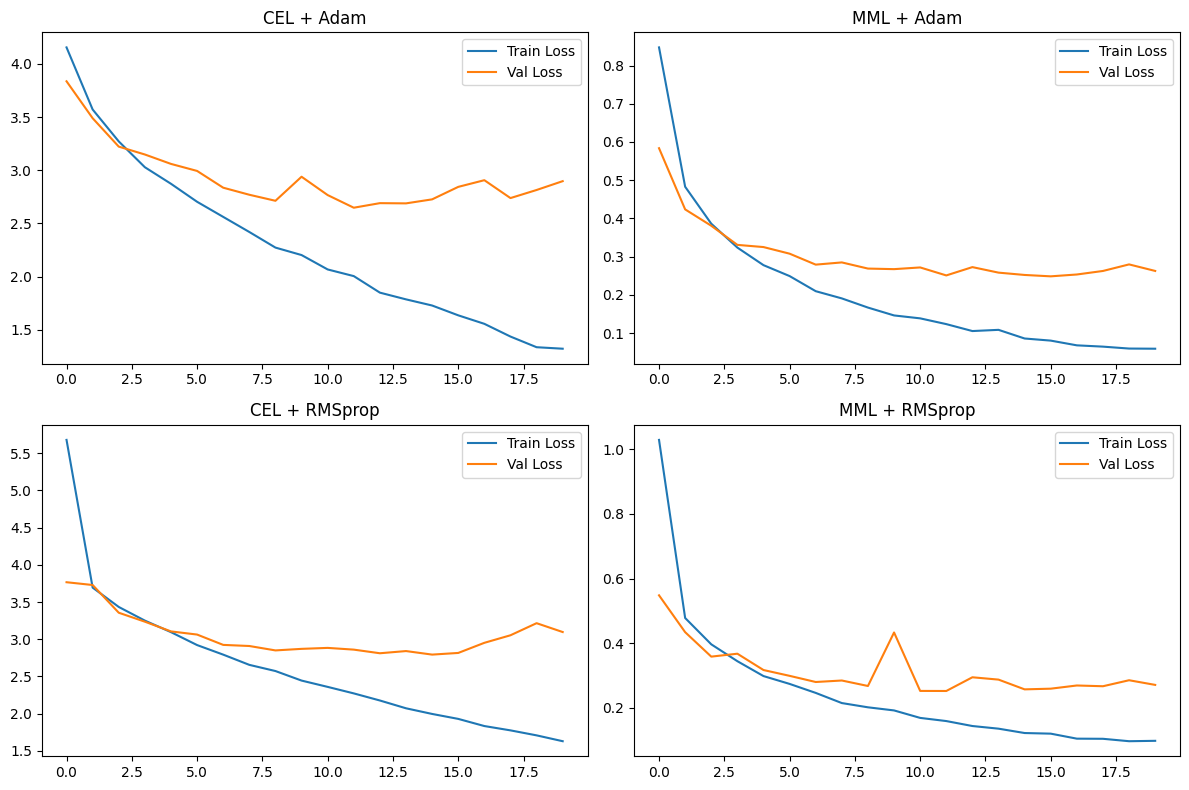

In [ ]:
# curvas de loss
plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
plt.plot(train_losses_B1, label='Train Loss')
plt.plot(val_losses_B1, label='Val Loss')
plt.title('CEL + Adam')
plt.legend()
plt.subplot(2, 2, 2)
plt.plot(train_losses_B2, label='Train Loss')
plt.plot(val_losses_B2, label='Val Loss')
plt.title('MML + Adam')
plt.legend()
plt.subplot(2, 2, 3)
plt.plot(train_losses_B3, label='Train Loss')
plt.plot(val_losses_B3, label='Val Loss')
plt.title('CEL + RMSprop')
plt.legend()
plt.subplot(2, 2, 4)
plt.plot(train_losses_B4, label='Train Loss')
plt.plot(val_losses_B4, label='Val Loss')
plt.title('MML + RMSprop')
plt.legend()
plt.tight_layout()
plt.show()